In [1]:
#this cell allows me to do forking in my process, seen in the cross section calculation
#multiprocessing allows for the use of multiple cores in your laptop/computer
#have to run this FIRST and only ONCE

import multiprocessing
multiprocessing.set_start_method("fork")

In [2]:
#here I am important a bunch of libraries I will need to do my calculations

import numpy as np
import math
import scipy
from scipy.interpolate import RectBivariateSpline as rect
from scipy.special import yn
from scipy.special import kn
import time
import jax
import jax.numpy as jnp
from jax import grad
from scipy.integrate import odeint
from scipy.differentiate import derivative

In [3]:
#this cell defines (in GeV natural units) mass of electrons and mass of muons
#also, using a table, it defines gstar (effective number of relativistic d.o.f.) 
#and gstarS (effective number of d.o.f. in entropy) as a function of mass 

#EVERYTHING IS IN GEV
me = 0.511e-3
mmu = 0.1057

gdata = np.loadtxt("microomegas.tab")

#delete first three rows of data
gdata=np.delete(gdata, [0,1,2], 0)
#print(gdata)

mass_col = gdata[:,0]

def gStarInt(m):
    gStarInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,2],bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarSInt(m):
    gStarSInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,1],bounds_error=False,fill_value="extrapolate")
    return gStarSInt(m)

m_values = np.logspace(-5, 1, num = 100)
#print(m_values)

gStarIntvalues = [gStarInt(m) for m in m_values]
gStarSIntvalues = [gStarSInt(m) for m in m_values]



In [4]:
#this cell utilizes the bose-einstein and fermi-dirac probability distribution functions to calculate 
#the gstar value for bosons (dark matter and axion particles) and fermions (electrons)
#it uses fd/be + integrates over this x parameter, which I think is energy of the particle 
#then it allows for the gstar values to be calculated for various species 

def funcfermion(mchi, T):
    return (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1)) 

def funcboson(mchi, T):
    return (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1))

#can try scipy.special.expit for the funcfermion, funcboson to possibly deal with any issues
#need to check documentation of this function

def gStarFermion(mchi, T, gchi):
    funcfermion = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1)) 
    integration = scipy.integrate.quad(funcfermion, a = mchi, b = np.inf, args = (mchi, T))
    gStarFermion = ((gchi*30)/(2*(math.pi**4)*(T**4))) * integration[0] 
    return gStarFermion

def gStarBoson(mchi, T, gchi):
    funcboson = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1)) 
    integration = scipy.integrate.quad(funcboson, a = mchi, b = np.inf, args = (mchi, T))
    #print(integration)
    gStarBoson = ((gchi*30)/(2*(math.pi**4)*(T**4))) * integration[0]
    #print(gStarBoson)
    return gStarBoson

dm_mass_values = np.logspace(-2.3, 2, num = 215)
ap_mass_values = np.logspace(-2.3, 2, num = 215)
ee_mass_values = np.logspace(-2.3, 2, num = 215)

gStarDMvalues = [gStarBoson(1, 1/m, 2) for m in dm_mass_values]
gStarAPvalues = [gStarBoson(1, 1/m, 3) for m in ap_mass_values]
gStarEEvalues = [gStarFermion(1, 1/m, 4) for m in ee_mass_values]


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_91676/2759920834.py:22: RuntimeWarning: overflow encountered in exp
  funcboson = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_91676/2759920834.py:16: RuntimeWarning: overflow encountered in exp
  funcfermion = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1))


In [5]:
#this cell does a 1D interperlation of the previous cell so you can easily get gStar for each mass
#also I set plank mass
def gStarDMInt(m):
    gStarInt = scipy.interpolate.interp1d(dm_mass_values, gStarDMvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarAPInt(m):
    gStarInt = scipy.interpolate.interp1d(ap_mass_values, gStarAPvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarEEInt(m):
    gStarInt = scipy.interpolate.interp1d(ee_mass_values, gStarEEvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

#setting cosmological parameters
m_pl = 1.22e19 #GeV
#now need to set up the functions.......

In [6]:
#this cell takes the previous cell and it's output, and does a more accurate gStar calculation by what formula, I'm not sure.....

def gStarTrue(T, mchi):
    Td = 0.002
    
    #what is Td and how is it chosen? 

    gDMDec = gStarDMInt((mchi/Td)) + gStarAPInt((3*mchi/Td))

    geDec = gStarEEInt((me/Td))

    if T > Td:
        answer = gStarInt(T) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T))
        return answer
    else:
        answer = 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*(mchi/T))) + (2*3*(7/8))*(( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec))*math.cbrt((( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec)))
        return answer

#NOTE: in the mathematica code, this was essentially the same as the previous function, but I do have a gstarS function....
def gStarSTrue(T, mchi):
    Td = 0.002
    
    #what is Td and how is it chosen? 

    gDMDec = gStarDMInt((mchi/Td)) + gStarAPInt((3*mchi/Td))

    geDec = gStarEEInt((me/Td))

    if T > Td:
        answer = gStarInt(T) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T))
        return answer
    else:
        answer = 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)) + (2*3*(7/8))*(( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec))
        return answer

temps = np.logspace(-6, 2, num = 215)
masses = np.logspace(-3, 1, num = 215)
#gStarSTrue_test = [gStarSTrue(t, m) for t in temps for m in masses]

gStarSTrue_np = np.frompyfunc(gStarSTrue, 2, 1)
gStarTrue_np = np.frompyfunc(gStarTrue, 2, 1)
Temps, Masses = np.meshgrid(temps, masses)


In [7]:
#I calculate gStarS and gStar and then create a interperlator to calculate it easily for each temperature

gStarSTrue_answers_load = np.loadtxt("gStarSTrue_answers.csv", delimiter=",")
gStarTrue_answers_load = np.loadtxt("gStarTrue_answers.csv", delimiter=",")
interp_spline_gStarS = rect(masses, temps, gStarSTrue_answers_load)
interp_spline_gStar = rect(masses, temps, gStarTrue_answers_load)

temps2 = np.logspace(-6, 2, num = 500)
masses2 = np.logspace(-3, 1, num = 500)

Temps2, Masses2 = np.meshgrid(temps2, masses2)

gStarSTrue_answers2Int = interp_spline_gStarS(masses2, temps2)
gStarTrue_answers2Int = interp_spline_gStar(masses2, temps2)

temps3 = np.logspace(-3, -2.5, num = 250)
temps4 = np.logspace(-4, -1.5, num = 250)

y_gStarSTrue = gStarSTrue_np(temps4, 0.004)
y_gStarTrue = gStarTrue_np(temps3, 0.004)
y_gStarTrue = [x.item() for x in y_gStarTrue]
y_gStarSTrue = [x.item() for x in y_gStarSTrue]
#print(y_gStarTrue)

y_gStarS= interp_spline_gStarS(0.004, temps4)
y_gStar = interp_spline_gStar(0.004, temps3)
#print(y_gStar)

y_gStarSInt = [gStarSInt(t) for t in temps4]
y_gStarInt = [gStarInt(t) for t in temps3]


In [8]:
#setting plank mass in GeV

m_planck = 1.22e19 #GeV

In [9]:
#calculating the energy density as a function of gStar and T and mchi
#answer comes from number density -> energy density -> to computing the high energy and low energy limits
#should the pi be squared????

def rho(T, mchi):
    gStar_value = interp_spline_gStar(mchi, T)
    answer = (math.pi*math.pi/30)*gStar_value[0][0]*(T**4)
    return answer

In [10]:
#making this a numpy function, so it can easily calculate the values from a mpy array

rho_np = np.frompyfunc(rho, 2, 1)

In [11]:
#calculating the hubble constant, this comes from utilizing the friedmann equations

def hubble(T, mchi):
    rho_value = rho(T, mchi)
    answer = math.sqrt((8*math.pi/(3*m_planck*m_planck))*rho_value)
    return answer

In [12]:
#making a numpy function again

hubble_np = np.frompyfunc(hubble, 2, 1)

In [13]:
#s is the entropy density, a conserved quantity, a function of mchi, T
#this equation is verified from my notes

def s_value(T, mchi):
    gStarS_value = interp_spline_gStarS(mchi, T)
    #print(gStarS_value[0][0])
    answer = (2*math.pi*math.pi/45)*gStarS_value[0][0]*(T**3)
    #jax_answer = jnp.array(answer)
    return answer

In [15]:
#making a numpy function

s_value_np = np.frompyfunc(s_value, 2, 1)

In [14]:
#CLAUDE WROTE THIS
#I need to verify this equation
#I use this function for my ODE

def ds_dT(T, mchi):
    """Derivative of entropy density s w.r.t. temperature T.

    s(T, mchi) = (2*pi*pi/45) * gStarS(mchi, T) * T^3

    By the product rule:
    ds/dT = (2*pi*pi/45) * [ dgStarS/dT * T^3 + gStarS * 3*T^2 ]

    RectBivariateSpline supports dy=1 to compute dgStarS/dT directly.
    """
    gStarS = interp_spline_gStarS(mchi, T)[0][0]
    dgStarS_dT = interp_spline_gStarS(mchi, T, dy=1)[0][0]
    return (2 * math.pi *math.pi/ 45) * (dgStarS_dT * T**3 + gStarS * 3 * T**2)

In [15]:
#this is calculating the y eq, which is ????
#I think this is the yield at matter/radiation equality (VERIFY)
#FIGURE THIS OUT

def y_eq(gchi, mchi, T):
    svalue = s_value(T, mchi)
    ratio = mchi/T
    bessel_value = kn(2, ratio)
    fraction = (gchi*mchi*mchi*T)/(2*math.pi*math.pi)
    answer = fraction*(bessel_value/svalue)
    return answer

In [16]:
#making a numpy function again

y_eq_np = np.frompyfunc(y_eq, 3, 1)

In [13]:
#now calculating the r ratio data
#first will start with importing the data

In [17]:
#inputting the R data, which was provided to me

rdataraw = np.loadtxt("R_ratio.dat", skiprows = 52, usecols = (0,1,2,3), max_rows = 1393)

In [18]:
#I need to figure out what R data is exactly..... but separating the data into different columns

EDMRData = rdataraw[:,0]
RData = rdataraw[:,3]

In [19]:
#here, I create an interperlation function using the EDMR data as x, R data as y

def rInt(x):
    r_Int = scipy.interpolate.interp1d(EDMRData, RData,bounds_error=False,fill_value="extrapolate")
    return r_Int(x)

In [20]:
#IMPORTANT TO NOTE, the given x is already the sqrt value, then I use the interperlation function created in the cell above for a specific range

def rFunc(x):
    #sqrt = math.sqrt(x)
    sqrt = x
    if sqrt < 4 and sqrt > 0.3:
        answer1 = rInt(sqrt)
        answer = answer1
    else:
        answer = 0
    return answer

In [21]:
#this must calculate something regarding the dark photon mediator, but what ?????
#get a reference!

#perhaps can call rFunc in the beginning of the function, but I think that it won't help here, maybe it will 
#be better if I calculate it, then pass it as a variable? we'll see in the rewrite.......
def gammaA(eps, sqrts, mchi, mA):
    result = 0 
    '''If[2 mchi < sqrts, (4 \[Pi]*0.5)/(48 \[Pi])
       sqrts (1 - 4 mchi^2/sqrts^2)^(3/2), 0]'''
    
    if 2*mchi < sqrts:
        #result += ((4*math.pi*0.5)/(48*math.pi)) * sqrts * math.pow((1 - 4*(mchi/sqrts)*(mchi/sqrts)), 1.5) 
        result += ((4*math.pi*0.5)/(48*math.pi)) * sqrts * math.pow((1 - 4*((mchi*mchi)/(sqrts*sqrts))), 1.5)
    if 2*mmu < sqrts:
        #this might be a problem area...... 
        result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*math.sqrt(1 - ((4*mmu*mmu)/(sqrts*sqrts)))*(sqrts/(12*math.pi))*(1 + ((2*mmu*mmu)/(sqrts*sqrts)))*(1+rFunc(sqrts))

    if 2*me < sqrts:
        result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*(sqrts/(12*math.pi))*math.sqrt(1- ((4*me*me)/(sqrts*sqrts)))*(1 + ((2*me*me)/(sqrts*sqrts)))
    #result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*(sqrts/(12*math.pi))*math.sqrt(1- ((4*me*me)/(sqrts*sqrts)))*(1 + ((2*me*me)/(sqrts*sqrts)))
    return result

In [23]:
#making a numpy function

gammaA_np = np.frompyfunc(gammaA, 4, 1)

In [22]:
#this was to try parallelizing the integration, was not helpful

worker_num = 1

In [23]:
#need to delete the unnecesary parts, I am also wondering if there are some issues with the 
#different cases of x, that I worked with earlier
def sigmave(x, T, eps, mchi, mA):
    call_value = 2*mchi*math.sqrt(x)
    ratio1 = (2*mchi*math.sqrt(x))/T

    
    
    if x - 1 < 0:
        print("What the HELLY") 
        
    num1 = 4*mchi*mchi*(math.sqrt(4*mchi*mchi*(x-1))*math.sqrt(4*mchi*mchi*x - 4*me*me)*(2*me*me + 4*mchi*mchi*x))
    num2 = (4*mchi*mchi*(x-1))*2*mchi*math.sqrt(x)*kn(1, ratio1)
    num = num1*num2
    
    denom = (12*math.pi*(4*mchi*mchi*x)*(math.pow((mA*mA - 4*mchi*mchi*x),2) + mA*mA*math.pow(gammaA(eps, call_value, mchi, mA), 2)))
    
    answer = num/denom


    return answer

In [24]:
def sigmavAnalytice(T, eps, mchi, mA):
    #from __main__ import sigmave
    #does not need above line with fork being set as start method!
    ratio = mchi/T
    bessel_value = kn(2, ratio)
    break_point = (mA*mA)/(4*mchi*mchi)
    
    constant_num = ((4*math.pi)/137)*math.pow((eps*math.sqrt(4*math.pi*0.5)), 2)
    constant_denom = 8*math.pow(mchi, 4)*T*math.pow(bessel_value,2)
    constant = constant_num/constant_denom
    
    #print(constant)
    
    break_point_minus = break_point - 1e-17*break_point
    break_point_plus = break_point + 1e-17*break_point
    
    if break_point <1:
        
        integrand = scipy.integrate.quad_vec(sigmave, 1, np.inf, args = (T, eps, mchi, mA), epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
        answer = constant*integrand[0]

    if break_point > 1:
        if break_point_minus < 1: 
            print("HOUSTON WE HAVE A PROBLEM")
        
        integrand_lower = scipy.integrate.quad_vec(sigmave, 1, break_point_minus, args = (T, eps, mchi, mA), epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
        
        integrand_plus = scipy.integrate.quad_vec(sigmave, break_point_plus, np.inf, args = (T, eps, mchi, mA), epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
        answer = constant * (integrand_lower[0] + integrand_plus[0])
        
    return answer

In [25]:
def sigmavmu(x, T, eps, mchi, mA):
    call_value = 2*mchi*math.sqrt(x)
    ratio1 = (2*mchi*math.sqrt(x))/T

    num1 = 4*mchi*mchi*(math.sqrt(4*mchi*mchi*(x-1))*math.sqrt(4*mchi*mchi*x - 4*mmu*mmu)*(2*mmu*mmu + 4*mchi*mchi*x))
    num2 = (4*mchi*mchi*(x-1))*2*mchi*math.sqrt(x)*kn(1, ratio1)*(1 + rFunc(call_value))
    num = num1*num2
    
    denom = (12*math.pi*(4*mchi*mchi*x)*(math.pow((mA*mA - 4*mchi*mchi*x),2) + mA*mA*math.pow(gammaA(eps, call_value, mchi, mA), 2)))
    
    answer = num/denom

    return answer 

In [26]:
#need to set the break point plus/minus relative to the break point itself
#maybe break point/ 1000000000 ? something like this?
def sigmaAnalyticmu(T, eps, mchi, mA):
    #from __main__ import sigmavmu
    answer = 0
    
    ratio = mchi/T
    bessel_value = kn(2, ratio)

    constant_num = ((4*math.pi)/137)*math.pow((eps*math.sqrt(4*math.pi*0.5)), 2)
    constant_denom = 8*math.pow(mchi, 4)*T*math.pow(bessel_value,2)
    constant = constant_num/constant_denom

    max_test = (mmu*mmu)/(mchi*mchi)
    max_value = max(max_test, 1)
    
    break_point = (mA*mA)/(4*mchi*mchi)
    
    if mchi > mmu/5:
        if ((mmu*mmu)/(mchi*mchi)) < ((mA*mA)/(4*mchi*mchi)):
            if break_point > max_value:
                break_point_minus = break_point - 1e-17*break_point
                break_point_plus = break_point + 1e-17*break_point
            
                integrand_lower = scipy.integrate.quad_vec(sigmavmu, max_value, break_point_minus, args = (T, eps, mchi, mA) , epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
                integrand_plus = scipy.integrate.quad_vec(sigmavmu, break_point_plus, np.inf, args = (T, eps, mchi, mA),epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
                result = (integrand_lower[0] + integrand_plus[0])
            else:
                integrand = scipy.integrate.quad_vec(sigmavmu, max_value, np.inf, args = (T, eps, mchi, mA), epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
                
                result = integrand[0]
        else:
            #this might need to be zero...........
            
            integrand = scipy.integrate.quad_vec(sigmavmu, max_value, np.inf, args = (T, eps, mchi, mA), epsabs=1e-6, epsrel=1e-3, limit=200, workers = worker_num)
            result = integrand[0]
        answer = constant*result
        
    return answer 

In [27]:
def sigmaAnalytic(x, eps, mchi):
    mA = 3*mchi
    T = mchi/x
    answer = sigmavAnalytice(T, eps, mchi, mA) + sigmaAnalyticmu(T, eps, mchi, mA)
    return answer

In [30]:
sigmavAnalytic_np = np.frompyfunc(sigmaAnalytic, 3, 1)

In [29]:
mchi_test = np.logspace(-3.1, 0.06, num = 100)
x_test = np.logspace(0, 2.5, num = 100)
eps_test = np.logspace(-5.9, 0.4, num = 100)
T_test = mchi_test/x_test
mA_test = 3*mchi_test

0.009602069854736328


In [33]:
#DO NOT RUN
#THIS IS FOR SHOWING HOW I DID THE LARGE RUN

from scipy.interpolate import RegularGridInterpolator
from multiprocessing.pool import Pool
#Temps, Eps, Mchis = np.meshgrid(T_test, eps_test, mchi_test, indexing = "ij",  sparse = True)
#print(Temps)
#input_vals_mesh = zip(Temps.ravel(), Eps.ravel(), Mchis.ravel())
#input_vals_test = zip(Temps, Eps, Mchis)
start_2 = time.time()
values_list = []
x_list = []
eps_list = []
mchi_list = []
final_array_x = np.ones((len(x_test), len(eps_test), len(mchi_test)))
#print(time.time() - start_2)
start_3 = time.time()
for k in range(len(mchi_test)):
    for j in range(len(eps_test)):
        for i in range(len(x_test)):
            values_list.append((x_test[i], eps_test[j], mchi_test[k]))
            #x_list.append(x_test[i])
            #eps_list.append(eps_test[j])
            #mchi_list.append(mchi_test[k])
            
#print(time.time() - start_3)
#x_array = np.array(x_list)
#eps_array = np.array(eps_list)
#mchi_array = np.array(mchi_list)
#print(x_array.shape)
#print(eps_array.shape)

#np_array_values = np.array(values_list)
#print(np_array_values.shape)

start_testtime = time.time()

#result_data_np = sigmavAnalytic_np(x_array, eps_array, mchi_array)
#print("vectorization time on 5x5x5", time.time() - start_testtime)
#print("numpy vector time", time.time() - start_testtime)
'''
for i in T_test:
    for j in eps_test:
        for k in mchi_test:
            values_list.append((i,j,k))'''

#print(len(values_list))
#print(values_list[0])
counter = 0
start_4 = time.time()

time_pool = time.time()   
if __name__ == "__main__":
    with Pool() as pool:
        result_data = pool.starmap(sigmaAnalytic, values_list, chunksize = 5)

#print(result_data == result_data_np)
print("time of pool", time.time() - start_4)

#print(time.time() - start_4)
#start_5 = time.time()

for k in range(len(mchi_test)):
    for j in range(len(eps_test)):
        for i in range(len(x_test)):
            final_array_x[int(i), int(j), int(k)] = result_data[counter]
            counter += 1
#print(time.time() - start_2)
#NEXT STEP REMOVE MA AS INPUT PARAMETER AND SET MA = 3*MCHI


time of pool 7117.448385000229


In [34]:
#also do not run
np.save("log10sigmavScalarTabx.npy", final_array_x)

In [32]:
worker_num = 1

In [30]:
from scipy.interpolate import RegularGridInterpolator

final_array_x = np.load("log10sigmavScalarTabx.npy")

log10_sigmav_x = np.log10(final_array_x)

interp_log10_x3 = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, method = "cubic", bounds_error=False, fill_value=None)
interp_log10_x = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, bounds_error=False, fill_value=None)

[-12.11242536]
-12.112425355651137


In [31]:
import pandas as pd
mathematica_sigmas = pd.read_csv("log10sigmavScalarTab.csv")
print(mathematica_sigmas)

        x1   x2   x3  log10sigmav
0     -3.0 -1.0 -5.6    -9.499971
1     -3.0 -1.0 -5.3    -8.899971
2     -3.0 -1.0 -5.0    -8.299971
3     -3.0 -1.0 -4.7    -7.699971
4     -3.0 -1.0 -4.4    -7.099971
...    ...  ...  ...          ...
23647  0.2  2.4 -1.7    -7.701784
23648  0.2  2.4 -1.4    -7.101784
23649  0.2  2.4 -1.1    -6.501784
23650  0.2  2.4 -0.8    -5.901784
23651  0.2  2.4 -0.5    -5.301785

[23652 rows x 4 columns]


In [84]:
mathematica_sample = mathematica_sigmas.sample(300)
mathematica_np_sample = mathematica_sample.to_numpy()
count = 0
countlist = []
residual_list = []
for row in mathematica_np_sample:
    if row[1] >= 0 and row[0] <= 0.06:
        mchi = 10**(row[0])
        eps = 10**(row[2])
        x = 10**(row[1])
        #print("mathematica")
        mathematica_val = row[3]
        #print("python")
        python_val = interp_log10_x3([x, eps, mchi])
        mval_exp = 10**mathematica_val
        pval_exp = 10**python_val
        residual = (mval_exp - pval_exp)/mval_exp
        if residual >= 0.1:
            print("mchi", row[0], "eps", row[2], "x", row[1])
            print("mathematica", row[3], "python", python_val)
            print("residual", residual)
            
        countlist.append(count)
        count+=1
        residual_list.append(residual)
print(count)

mchi -0.3249999999999999 eps -5.6 x 1.2000000000000002
mathematica -12.98061734585357 python [-13.10179716]
residual [0.24348041]
mchi -0.475 eps -3.8 x 0.2000000000000001
mathematica -6.750731615800269 python [-6.95686225]
residual [0.37788687]
mchi -0.475 eps -4.3999999999999995 x 0.8
mathematica -8.572950541239688 python [-8.75215428]
residual [0.33809408]
mchi -0.2999999999999999 eps -2.9 x 1.2000000000000002
mathematica -7.745208029089993 python [-7.83068723]
residual [0.17866412]
mchi -0.475 eps -1.0999999999999996 x 0.2000000000000001
mathematica -1.354952142208444 python [-1.55812482]
residual [0.37363522]
200


Text(0, 0.5, 'Cubic Residual')

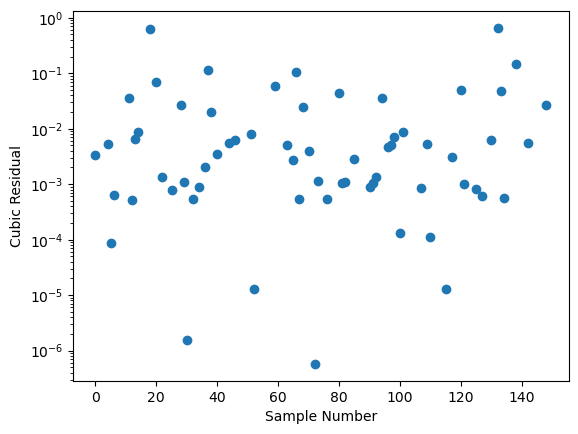

In [59]:
import matplotlib.pyplot as plt
plt.scatter(countlist, residual_list)
#plt.xscale('log'); 
plt.yscale('log')
#plt.title(f"Eps = {eps_val:.3e}")
plt.xlabel('Sample Number'); plt.ylabel('Cubic Residual')

In [32]:
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.differentiate import derivative

In [33]:
#from scipy.integrate import solve_ivp

def soln(y, x, gchi, mchi, eps):
    T = mchi / x
    
    s_val = s_value(T, mchi)
    ds_dT_val = ds_dT(T, mchi)
    
    sigmav_log10_x3 = interp_log10_x3([x, eps, mchi])[0]
    sigmav = 10**sigmav_log10_x3
    
    
    num1 = (s_val * sigmav) / (hubble(T, mchi) * x)
    num2 = (((1.0 / 3.0) * (T * ds_dT_val)) / s_val)
    #num3 = (y_eq(gchi, mchi, T)**2) * np.exp(-y) - np.exp(y)
    log_yeq = np.log(y_eq(gchi, mchi, T))
    log_term1 = 2 * log_yeq - y

    log_term2 = y

    if log_term1 > log_term2:
        num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
    else:
        num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
    
    return num1 * num2 * num3

In [34]:
def getsoln(gchi, mchi, eps, x_start, x_end, ode_method, rto, ato):
    x_span = (x_start, x_end)
    x_eval_log = np.logspace(math.log10(x_start), math.log10(x_end), 100)
    x_eval_log = np.clip(x_eval_log, x_span[0], x_span[1])
    y0 = [np.log(y_eq(gchi, mchi, mchi / x_span[0]))]

    
    sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                    x_span, y0, method=ode_method,
                    t_eval=x_eval_log, rtol=rto, atol=ato)

    # Retry with Radau and tighter tolerances if failed
    if not sol.success:
        print("trying again")
        print("mchi: ", mchi, "eps: ", eps)
        sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                        x_span, y0, method="Radau",
                        t_eval=x_eval_log, rtol=1e-4, atol=1e-6)

    # Last resort: try with dense output and looser tolerances
    if not sol.success:
        print("trying again again")
        sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                        x_span, y0, method="Radau",
                        t_eval=x_eval_log, rtol=1e-6, atol=1e-8)

    if not sol.success:
        print(f"Warning — all methods failed: mchi={mchi:.3e}, eps={eps:.3e}: {sol.message}")

    return sol

In [35]:
#DO NOT RUN
from multiprocessing.pool import Pool
values_list_full = []
values_list_one = []

mx_values_ode = np.logspace(-3.1, 0.06, 10)
eps_values_ode_full = np.logspace(-5.9, -1, 4)
eps_values_ode_one = np.logspace(-5.3, -0.5, 4)

ode_full_array = np.ones((len(mx_values_ode), len(eps_values_ode_full)))
ode_one_array = np.ones((len(mx_values_ode), len(eps_values_ode_one)))
ode_full_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_full)))
ode_one_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_one)))

ode_full_list = []
ode_one_list = []
#ode_full_list_m = []
#ode_one_list_m = []

counter_full = 0
counter_one = 0
start_3 = time.time()
for j in range(len(eps_values_ode_full)):
    for i in range(len(mx_values_ode)):
        #print(i,j)
        values_list_full.append((1, mx_values_ode[i], eps_values_ode_full[j], 1, 200, "Radau", 1e-3, 1e-5))
        values_list_one.append((1, mx_values_ode[i], eps_values_ode_one[j], 1, 200, "Radau", 1e-3, 1e-5))
        #test_full = getsoln(1, mx_values_ode[i], eps_values_ode_full[j], 1, 200)
        #test_full_val = test_full.y[0][-1]
        #test_one = getsoln(1, mx_values_ode[i], eps_values_ode_one[j], 1, 200)
        #test_one_val = test_one.y[0][-1]
        #ode_full_list.append(math.exp(test_full_val))
        #ode_one_list.append(math.exp(test_one_val))
        
if __name__ == "__main__":
    with Pool() as pool:
        result_data_full = pool.starmap(getsoln, values_list_full, chunksize = 5)
        result_data_one = pool.starmap(getsoln, values_list_one, chunksize = 5)
        #result_data_full = result_data_full.y[0][-1]
        #result_data_one = result_data_one.y[0][-1]
print(time.time() - start_3)

ode_full_list = [math.exp(sol.y[0][-1]) for sol in result_data_full]
ode_one_list  = [math.exp(sol.y[0][-1]) for sol in result_data_one]


for j in range(len(eps_values_ode_full)):
    for i in range(len(mx_values_ode)):
        ode_full_array[int(i), int(j)] = ode_full_list[counter_full]
        ode_full_array_m[int(i), int(j)] = mx_values_ode[i]*ode_full_list[counter_full]
        counter_full += 1
        ode_one_array[int(i), int(j)] = ode_one_list[counter_one]
        ode_one_array_m[int(i), int(j)] = mx_values_ode[i]*ode_one_list[counter_one]
        counter_one += 1


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:44: RuntimeWarning: overflow encountered in exp
  num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:44: RuntimeWarning: overflow encountered in exp
  num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gq

4.418856143951416


In [61]:
'''np.save("FullAbundanceTab.npy", ode_full_array)
np.save("OneAbundanceTab.npy", ode_one_array)
np.save("FullAbundanceTabM.npy", ode_full_array_m)
np.save("OneAbundanceTabM.npy", ode_one_array_m)'''

ode_full_array = np.load("FullAbundanceTab.npy")
ode_one_array = np.load("OneAbundanceTab.npy")
ode_full_array_m = np.load("FullAbundanceTabM.npy")
ode_one_array_m = np.load("OneAbundanceTabM.npy")

In [127]:
mx_values_ode = np.logspace(-3.1, 0.06, 100)
eps_values_ode_full = np.logspace(-5.9, -1, 40)
eps_values_ode_one = np.logspace(-5.3, -0.5, 40)
from scipy.interpolate import RegularGridInterpolator

interp_full_m = RegularGridInterpolator((mx_values_ode, eps_values_ode_full), np.log10(ode_full_array_m), method='cubic', bounds_error=False, fill_value=None)
interp_one_m = RegularGridInterpolator((mx_values_ode, eps_values_ode_one), np.log10(ode_one_array_m), method='cubic', bounds_error=False, fill_value=None)

In [149]:
from scipy import optimize
count_bad_values_full = 0
count_bad_values_one = 0
eps_full_tab = np.ones((len(mx_values_ode), 2))
eps_one_tab = np.ones((len(mx_values_ode), 2))
#YFullAbundance = np.ones((len(mx_values_ode), len(mx_values_ode)))
#YOneAbundance = np.ones((len(mx_values_ode), len(eps_values_ode_one)))
target = (4.32e-10)/2

def root_function_full(ep, mx):
    #print(mx, type(mx))
    #print(ep, type(ep))
    
    interp_value = interp_full_m((mx, ep))
    diff = 10**interp_value - target
    return diff
def root_function_one(ep, mx):
    interp_value_one = interp_one_m((mx, ep))
    diff_one = 10**interp_value_one - target
    return diff_one
for i in range(len(mx_values_ode)):
    #root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
    #root_one = optimize.brentq(root_function_one, a = eps_values_ode_one[0], b = eps_values_ode_one[-1], xtol = math.pow(10, -2.5), args = (mx_values_ode[i]))
    #eps_full_tab[i][0] = mx_values_ode[i]
    #eps_full_tab[i][1] = root_full
    #eps_one_tab[i][0] = mx_values_ode[i]
    #eps_one_tab[i][1] = root_one
    if np.sign(root_function_full(eps_values_ode_full[0], mx_values_ode[i])) == np.sign(root_function_full(eps_values_ode_full[-1], mx_values_ode[i])):
        print("ERROR", math.log10(mx_values_ode[i]))
        count_bad_values_full += 1
        eps_full_tab[i][0] = mx_values_ode[i]
        eps_full_tab[i][1] = math.nan
    else:
        root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
        eps_full_tab[i][0] = mx_values_ode[i]
        eps_full_tab[i][1] = root_full
    if np.sign(root_function_one(eps_values_ode_one[0], mx_values_ode[i])) == np.sign(root_function_one(eps_values_ode_one[-1], mx_values_ode[i])):
        print("ERROR", math.log10(mx_values_ode[i]))
        count_bad_values_one += 1
        eps_one_tab[i][0] = mx_values_ode[i]
        eps_one_tab[i][1] = math.nan
    else:
        ###
        #print("success")
        #root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
        root_one = optimize.brentq(root_function_one, a = eps_values_ode_one[0], b = eps_values_ode_one[-1], xtol = math.pow(10, -2.5), args = (mx_values_ode[i]))
        #eps_full_tab[i][0] = mx_values_ode[i]
        #eps_full_tab[i][1] = root_full
        eps_one_tab[i][0] = mx_values_ode[i]
        eps_one_tab[i][1] = root_one

ERROR -3.1
ERROR -3.068080808080808


In [150]:
eps_one_tab_complete = eps_one_tab[~np.isnan(eps_one_tab).any(axis = 1)]
eps_full_tab_complete = eps_full_tab[~np.isnan(eps_full_tab).any(axis = 1)]
#print(eps_full_tab_complete[:,0])
#print(eps_full_tab_complete)

In [151]:
#print(eps_one_tab)
'''def gStarInt(m):
    gStarInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,2],bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)'''

def epsFullInt(m):
    epsFullInt = scipy.interpolate.interp1d(eps_full_tab_complete[:,0], eps_full_tab_complete[:,1],bounds_error=False,fill_value="extrapolate")
    return epsFullInt(m)

def epsOneInt(m):
    epsOneInt = scipy.interpolate.interp1d(eps_one_tab_complete[:,0], eps_one_tab_complete[:,1],bounds_error=False,fill_value="extrapolate")
    return epsOneInt(m)

In [152]:
def sigmaBareFull(mx):
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    num1 = (epsFullInt(mx) * math.sqrt(4*math.pi*0.5)) ** 2
    num2 = 16*math.pi*mu_val*mu_val * (1/137)
    square_val = (3*mx)**2 + (1/137)**2 + (0.511e-3)**2
    denom = 4*math.pi*math.pow(square_val, 2)
    ans = (num1*num2)/denom
    return ans

In [153]:
def sigmaBareOne(mx):
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    num1 = (epsOneInt(mx) * math.sqrt(4*math.pi*0.5)) ** 2
    num2 = 16*math.pi*mu_val*mu_val * (1/137)
    square_val = (3*mx)**2 + (1/137)**2 + (0.511e-3)**2
    denom = 4*math.pi*math.pow(square_val, 2)
    ans = (num1*num2)/denom
    return ans

In [154]:
sigmaBareFull_np = np.frompyfunc(sigmaBareFull, 1, 1)
sigmaBareOne_np = np.frompyfunc(sigmaBareOne, 1, 1)

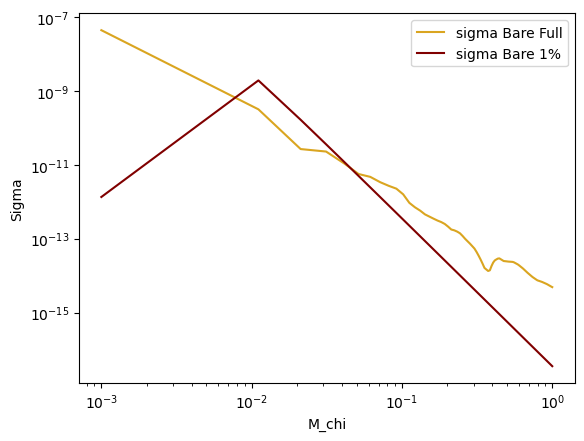

In [157]:
import matplotlib.pyplot as plt
m_vals = np.linspace(1e-3, 1, 100)

sigmaFull_vals = sigmaBareFull_np(m_vals)
sigmaOne_vals = sigmaBareOne_np(m_vals)

eps_Full_vals = [epsFullInt(i) for i in m_vals]
eps_One_vals = [epsOneInt(j) for j in m_vals]

plt.figure()
plt.plot(m_vals, sigmaFull_vals, label = "sigma Bare Full", color = "goldenrod")
plt.plot(m_vals, 0.01*sigmaOne_vals, label ="sigma Bare 1%", color = "maroon")

#plt.plot(m_vals, eps_Full_vals, color = "goldenrod",label =  "Eps Full")
#plt.plot(m_vals, eps_One_vals, color = "maroon", label = "Eps One Percent")

plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-15, 1e-7)
plt.xlabel('M_chi')
plt.ylabel('Sigma')
plt.legend()
plt.show()